In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sigfig import round
%run ./HFIR_Experiment_Functions.ipynb

In [2]:
#slow = pd.read_csv('nsrgsc_20240609_1_18.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240610_1_3.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240610_1_6.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240611_1_6.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240611_1_7.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240611_1_5.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240612_7_1.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240613_2_1.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240613_2_1_full.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240614_3_1.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240616_7_2.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240616_6_3.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240616_5_2.csv', header=None) #sunday morn
#slow = pd.read_csv('nsrgsc_20240617_8_4.csv', header=None) #monday night
slow = pd.read_csv('nsrgsc_20240617_8_6.csv', header=None) #tues morn
#slow = pd.read_csv('nsrgsc_20240619_9_17.csv', header=None)
#slow = pd.read_csv('nsrgsc_20240620_9_20.csv', header=None) #final one

In [3]:
begin=10
#start=1500
#end=len(slow)-7000
#end=15000
end=len(slow)
#end=5000

#start=10
#end=len(slow)

# Temperature readouts
TUSBR = np.float64(slow[2][begin:end])
TRADS = np.float64(slow[3][begin:end])
TDSTR = np.float64(slow[4][begin:end])
TDSBL = np.float64(slow[5][begin:end])
temps = [TUSBR,TDSTR,TDSBL]


# Fluxgate readouts, making the upstream ones negative and dividing x,y,z by 4
field1 = np.float64(slow[18][begin:end])
field2 = np.float64(slow[19][begin:end])
field3 = np.float64(slow[20][begin:end])
field4 = np.float64(slow[21][begin:end])
field5 = np.float64(slow[22][begin:end])
fieldx = np.float64(slow[23][begin:end])
fieldy = np.float64(slow[24][begin:end])
fieldz = np.float64(slow[25][begin:end])
error = np.float64(slow[6][begin:end])
index = np.float64(slow[0][begin:end])
time = np.float64(slow[1][begin:end])

# Lock-in amplifier readouts
lockin = np.float64(slow[6][begin:end])
lockin_set = np.float64(slow[7][begin:end])

fields=[field1,field2,field3,field4,field5,fieldx,fieldy,fieldz]
places=["DSTL", "DSTR", "DSBR", "USTL", "DSBL", "USTR", "USBR", "USBL"]

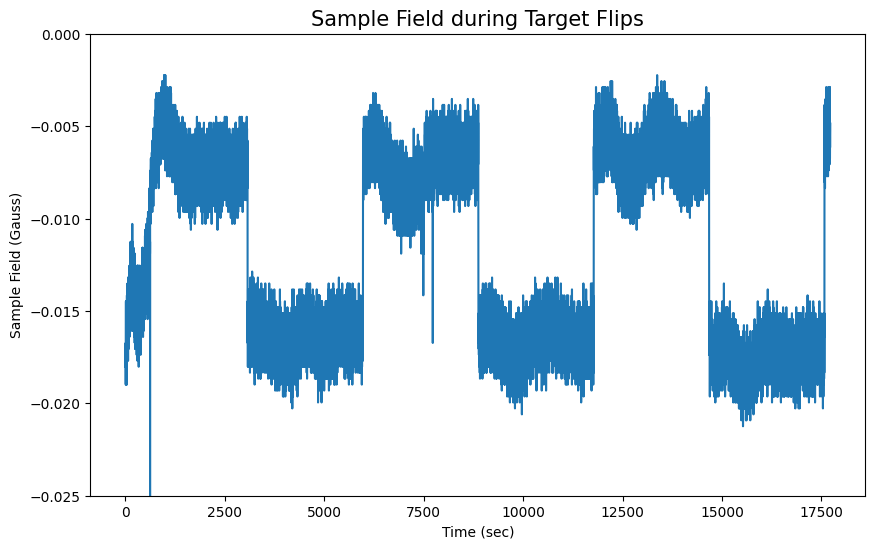

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

#plotting all but field 5

for i in [7]:
    ax.plot(time,fields[i],label = f"Field {i+1} {places[i]}")

SMALL_SIZE = 8
MEDIUM_SIZE = 12
BIGGER_SIZE = 15

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

ax.set_title("Sample Field during Target Flips")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Sample Field (Gauss)")
ax.set_ylim(-.025,0.000)

#ax.legend(loc="lower right")



#plt.savefig('HFIR_Sample_Flip_before.png',dpi=200)

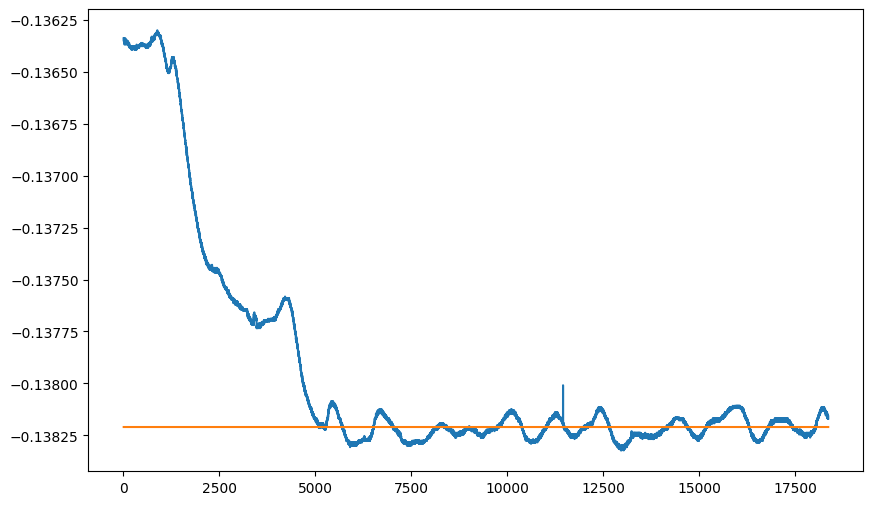

In [114]:
fig, ax = plt.subplots(figsize=(10, 6))

#for i in np.arange(len(temps)):
#    plt.plot(time,temps[i])

# Lock-in vs lock-in set
plt.plot(time,lockin)
plt.plot(time,lockin_set)

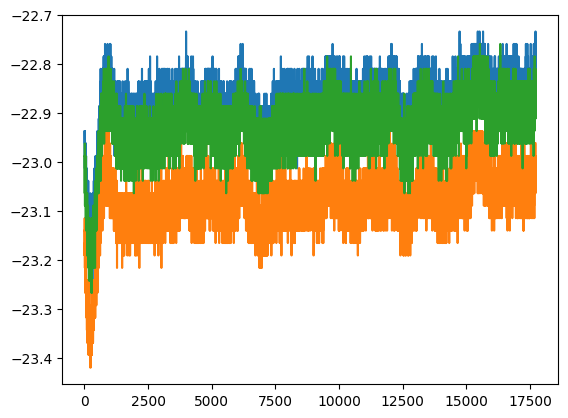

In [110]:
for i in np.arange(3):
    plt.plot(time,temps[i])

In [990]:
gen_cutoff(time,temps,fields,n)

list

In [5]:
n=60
temp=temps[0]
cutoffs=gen_cutoff(time,temp,fields,n)
field_avg(time,fieldy,cutoffs,-22.5,n)[2]

/var/folders/j0/7jz_gjk926qg0jds_8drhdch0000gn/T/ipykernel_13048/4021459648.py:17: RankWarning: Polyfit may be poorly conditioned
  fit=np.polyfit(temps,means,1)


IndexError: list index out of range

In [880]:
np.mean(fieldy[1:1000])

0.004130665165165165

In [844]:
np.mean(fieldy[1000-n:1000])

0.004142958333333333